### US and Canada Loan Approval Analysis

In this project, I analyze a dataset of 50,000 loan applications from 
the United States and Canada. My goal is to understand how financial 
behavior and debt levels affect interest rates, and to predict interest 
rates using regression models.

The dataset was downloaded from Kaggle:
https://www.kaggle.com/datasets/parthpatel2130/realistic-loan-approval-dataset-us-canada

## Dataset Columns

- customer_id: unique identifier for each applicant
- age: age of the applicant
- occupation_status: Employed, Self-Employed, or Student
- years_employed: number of years employed
- annual_income: annual income in dollars
- credit_score: credit score of the applicant
- credit_history_years: number of years of credit history
- savings_assets: total savings and assets in dollars
- current_debt: current total debt in dollars
- defaults_on_file: number of defaults on record
- delinquencies_last_2yrs: number of late payments in the last 2 years
- derogatory_marks: number of negative marks on credit history
- product_type: Credit Card, Personal Loan, or Line of Credit
- loan_intent: purpose of the loan
- loan_amount: amount requested in dollars
- interest_rate: interest rate offered (target variable)
- debt_to_income_ratio: ratio of debt to income
- loan_to_income_ratio: ratio of loan amount to income
- payment_to_income_ratio: ratio of monthly payment to income
- loan_status: 1 = approved, 0 = denied

## 1. Loading and Inspecting the Data

Before doing any cleaning, I first inspect the dataset to understand 
its structure, data types, and any potential problems.

In [1]:
import pandas as pd

# The CSV file must be in the same folder as this notebook
file_name = "Loan_approval_data_2025.csv"

df = pd.read_csv(file_name)

print("CSV file loaded successfully.")

CSV file loaded successfully.


In [2]:
print("Dataset shape:", df.shape)
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Dataset shape: (50000, 20)
Number of rows: 50000
Number of columns: 20


In [3]:
df.head(5)

,customer_id,age,occupation_status,years_employed,annual_income,credit_score,credit_history_years,savings_assets,current_debt,defaults_on_file,delinquencies_last_2yrs,derogatory_marks,product_type,loan_intent,loan_amount,interest_rate,debt_to_income_ratio,loan_to_income_ratio,payment_to_income_ratio,loan_status
0,CUST100000,40,Employed,17.2,25579,692,5.3,895,10820,0,0,0,Credit Card,Business,600,17.02,0.423,0.023,0.008,1
1,CUST100001,33,Employed,7.3,43087,627,3.5,169,16550,0,1,0,Personal Loan,Home Improvement,53300,14.10,0.384,1.237,0.412,0
2,CUST100002,42,Student,1.1,20840,689,8.4,17,7852,0,0,0,Credit Card,Debt Consolidation,2100,18.33,0.377,0.101,0.034,1
3,CUST100003,53,Student,0.5,29147,692,9.8,1480,11603,0,1,0,Credit Card,Business,2900,18.74,0.398,0.099,0.033,1
4,CUST100004,32,Employed,12.5,63657,630,7.2,209,12424,0,0,0,Personal Loan,Education,99600,13.92,0.195,1.565,0.522,1


In [4]:
print("Column names:")

for column in df.columns:
    print(column)

Column names:
customer_id
age
occupation_status
years_employed
annual_income
credit_score
credit_history_years
savings_assets
current_debt
defaults_on_file
delinquencies_last_2yrs
derogatory_marks
product_type
loan_intent
loan_amount
interest_rate
debt_to_income_ratio
loan_to_income_ratio
payment_to_income_ratio
loan_status


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customer_id              50000 non-null  object 
 1   age                      50000 non-null  int64  
 2   occupation_status        50000 non-null  object 
 3   years_employed           50000 non-null  float64
 4   annual_income            50000 non-null  int64  
 5   credit_score             50000 non-null  int64  
 6   credit_history_years     50000 non-null  float64
 7   savings_assets           50000 non-null  int64  
 8   current_debt             50000 non-null  int64  
 9   defaults_on_file         50000 non-null  int64  
 10  delinquencies_last_2yrs  50000 non-null  int64  
 11  derogatory_marks         50000 non-null  int64  
 12  product_type             50000 non-null  object 
 13  loan_intent              50000 non-null  object 
 14  loan_amount           

In [6]:
df.describe()

,age,years_employed,annual_income,credit_score,credit_history_years,savings_assets,current_debt,defaults_on_file,delinquencies_last_2yrs,derogatory_marks,loan_amount,interest_rate,debt_to_income_ratio,loan_to_income_ratio,payment_to_income_ratio,loan_status
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,34.957060,7.454868,50062.892040,643.614820,8.168274,3595.619400,14290.442220,0.053480,0.55464,0.147640,33041.874000,15.498591,0.285724,0.701999,0.233995,0.550460
std,11.118603,7.612097,32630.501014,64.731518,7.207552,13232.399398,13243.757493,0.224991,0.84505,0.412996,26116.185102,4.067942,0.159787,0.465788,0.155268,0.497452
min,18.000000,0.000000,15000.000000,348.000000,0.000000,0.000000,60.000000,0.000000,0.00000,0.000000,500.000000,6.000000,0.002000,0.008000,0.003000,0.000000
25%,26.000000,1.300000,27280.500000,600.000000,2.000000,130.000000,5581.000000,0.000000,0.00000,0.000000,12300.000000,12.180000,0.161000,0.333000,0.111000,0.000000
50%,35.000000,4.900000,41607.500000,643.000000,6.100000,568.000000,10385.000000,0.000000,0.00000,0.000000,26100.000000,15.440000,0.265000,0.622000,0.207000,1.000000
75%,43.000000,11.400000,62723.250000,687.000000,12.600000,2271.000000,18449.250000,0.000000,1.00000,0.000000,48500.000000,18.870000,0.389000,1.010250,0.337000,1.000000
max,70.000000,39.900000,250000.000000,850.000000,30.000000,300000.000000,163344.000000,1.000000,9.00000,4.000000,100000.000000,23.000000,0.800000,2.001000,0.667000,1.000000


In [7]:
df.describe(include="all")

,customer_id,age,occupation_status,years_employed,annual_income,credit_score,credit_history_years,savings_assets,current_debt,defaults_on_file,delinquencies_last_2yrs,derogatory_marks,product_type,loan_intent,loan_amount,interest_rate,debt_to_income_ratio,loan_to_income_ratio,payment_to_income_ratio,loan_status
count,50000,50000.000000,50000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000,50000,50000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
unique,50000,NaN,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,6,NaN,NaN,NaN,NaN,NaN,NaN
top,CUST100000,NaN,Employed,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Credit Card,Personal,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,NaN,34971,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,22455,12429,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,34.957060,NaN,7.454868,50062.892040,643.614820,8.168274,3595.619400,14290.442220,0.053480,0.55464,0.147640,NaN,NaN,33041.874000,15.498591,0.285724,0.701999,0.233995,0.550460
std,NaN,11.118603,NaN,7.612097,32630.501014,64.731518,7.207552,13232.399398,13243.757493,0.224991,0.84505,0.412996,NaN,NaN,26116.185102,4.067942,0.159787,0.465788,0.155268,0.497452
min,NaN,18.000000,NaN,0.000000,15000.000000,348.000000,0.000000,0.000000,60.000000,0.000000,0.00000,0.000000,NaN,NaN,500.000000,6.000000,0.002000,0.008000,0.003000,0.000000
25%,NaN,26.000000,NaN,1.300000,27280.500000,600.000000,2.000000,130.000000,5581.000000,0.000000,0.00000,0.000000,NaN,NaN,12300.000000,12.180000,0.161000,0.333000,0.111000,0.000000
50%,NaN,35.000000,NaN,4.900000,41607.500000,643.000000,6.100000,568.000000,10385.000000,0.000000,0.00000,0.000000,NaN,NaN,26100.000000,15.440000,0.265000,0.622000,0.207000,1.000000
75%,NaN,43.000000,NaN,11.400000,62723.250000,687.000000,12.600000,2271.000000,18449.250000,0.000000,1.00000,0.000000,NaN,NaN,48500.000000,18.870000,0.389000,1.010250,0.337000,1.000000


## 2. Data Cleaning

The inspection showed the dataset has 50,000 rows, 20 columns, and no 
missing values. However, I still need to remove the customer_id column 
since it is just an identifier, and check for duplicate rows.

In [8]:
print("Original dataset shape:", df.shape)

Original dataset shape: (50000, 20)


In [9]:
# Remove the identifier column
df_clean = df.drop(columns=["customer_id"]).copy()

print("Shape after removing customer_id:", df_clean.shape)

Shape after removing customer_id: (50000, 19)


In [10]:
# Count duplicate rows
duplicate_count = df_clean.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

# Remove duplicate rows
df_clean = df_clean.drop_duplicates().reset_index(drop=True)

print("Shape after removing duplicates:", df_clean.shape)

Number of duplicate rows: 0
Shape after removing duplicates: (50000, 19)


In [11]:
# Count missing values in each column
missing_values = df_clean.isnull().sum()

print("Missing values per column:")
print(missing_values)

Missing values per column:
age                        0
occupation_status          0
years_employed             0
annual_income              0
credit_score               0
credit_history_years       0
savings_assets             0
current_debt               0
defaults_on_file           0
delinquencies_last_2yrs    0
derogatory_marks           0
product_type               0
loan_intent                0
loan_amount                0
interest_rate              0
debt_to_income_ratio       0
loan_to_income_ratio       0
payment_to_income_ratio    0
loan_status                0
dtype: int64


In [12]:
print("Columns with missing values:")
print(missing_values[missing_values > 0])

Columns with missing values:
Series([], dtype: int64)


In [13]:
print("Final cleaned dataset shape:", df_clean.shape)
print("Final number of rows:", df_clean.shape[0])
print("Final number of columns:", df_clean.shape[1])

Final cleaned dataset shape: (50000, 19)
Final number of rows: 50000
Final number of columns: 19


In [14]:
import pandas as pd

# Preserve the original DataFrame
df_clean = df.copy()

print("Original dataset shape:", df_clean.shape)

# 1. Remove customer_id
df_clean = df_clean.drop(columns=["customer_id"])

# 2. Check for and remove duplicates
duplicate_count = df_clean.duplicated().sum()
print("\nNumber of duplicate rows:", duplicate_count)

df_clean = df_clean.drop_duplicates().reset_index(drop=True)

# 3. Check missing values
missing_values = df_clean.isnull().sum()

print("\nMissing values per column:")
print(missing_values)

print("\nTotal missing values:", missing_values.sum())

# 4. Show final shape
print("\nFinal cleaned dataset shape:", df_clean.shape)

Original dataset shape: (50000, 20)

Number of duplicate rows: 0

Missing values per column:
age                        0
occupation_status          0
years_employed             0
annual_income              0
credit_score               0
credit_history_years       0
savings_assets             0
current_debt               0
defaults_on_file           0
delinquencies_last_2yrs    0
derogatory_marks           0
product_type               0
loan_intent                0
loan_amount                0
interest_rate              0
debt_to_income_ratio       0
loan_to_income_ratio       0
payment_to_income_ratio    0
loan_status                0
dtype: int64

Total missing values: 0

Final cleaned dataset shape: (50000, 19)


## 3. Exploratory Data Analysis (EDA)

In this section, I explore the relationships between financial variables 
and the target variable interest_rate. I look at data distributions, 
relationships between variables, and how debt and credit behavior 
relate to loan outcomes.

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Use the cleaned dataset
data = df_clean.copy()

sns.set_theme(style="whitegrid")

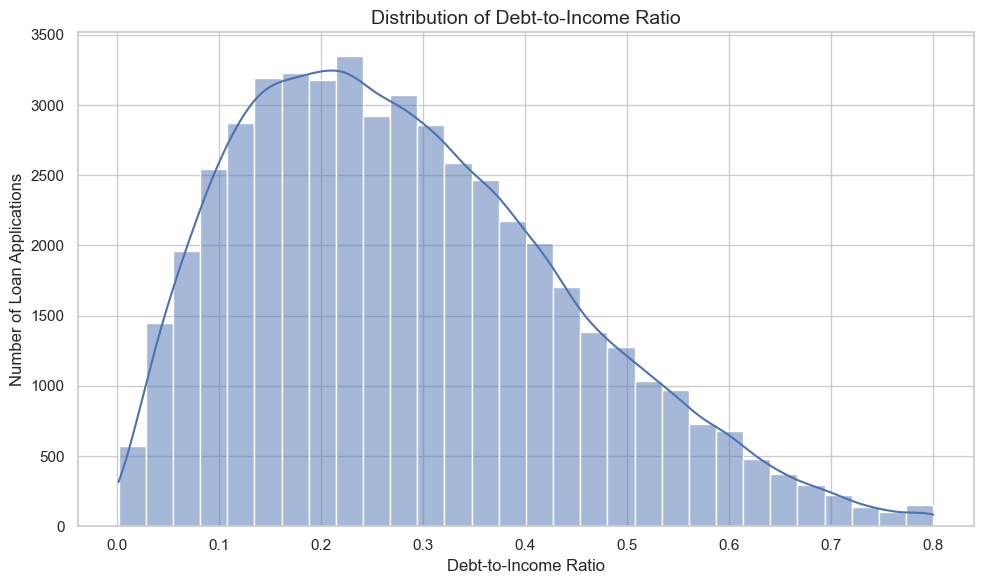

In [16]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=data,
    x="debt_to_income_ratio",
    bins=30,
    kde=True
)

plt.title("Distribution of Debt-to-Income Ratio", fontsize=14)
plt.xlabel("Debt-to-Income Ratio")
plt.ylabel("Number of Loan Applications")
plt.tight_layout()
plt.show()

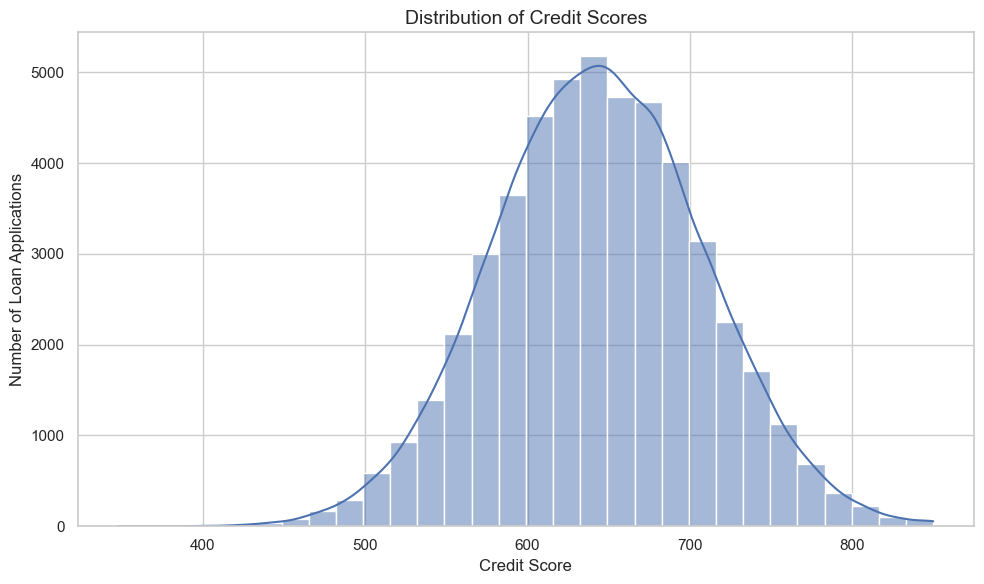

In [17]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=data,
    x="credit_score",
    bins=30,
    kde=True
)

plt.title("Distribution of Credit Scores", fontsize=14)
plt.xlabel("Credit Score")
plt.ylabel("Number of Loan Applications")
plt.tight_layout()
plt.show()

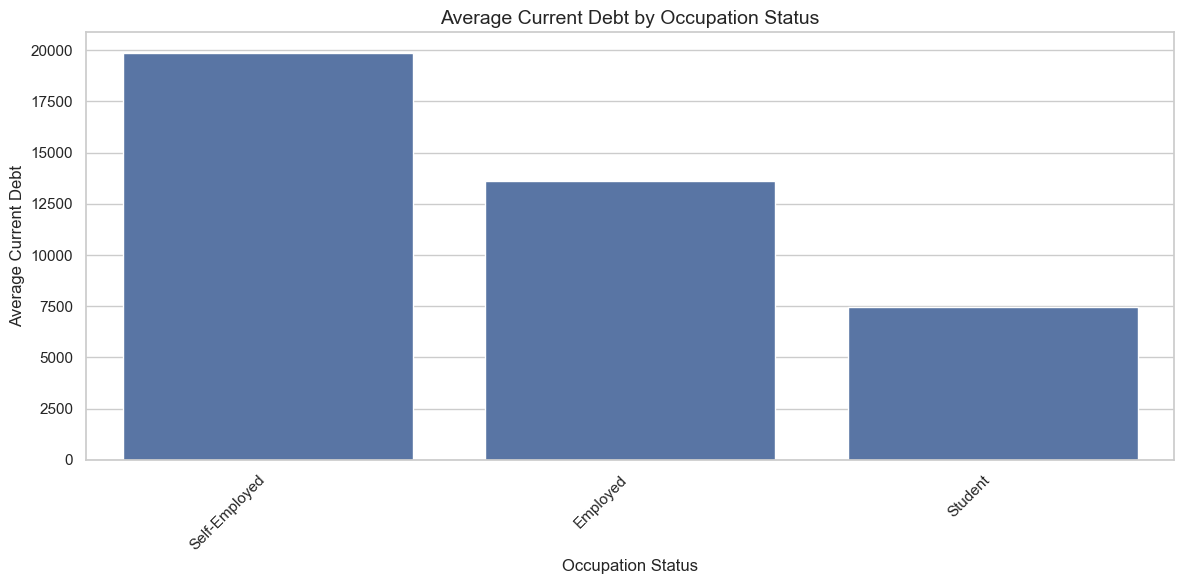

In [18]:
# Calculate average debt for each occupation status
average_debt_by_occupation = (
    data.groupby("occupation_status", as_index=False)["current_debt"]
    .mean()
    .sort_values("current_debt", ascending=False)
)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=average_debt_by_occupation,
    x="occupation_status",
    y="current_debt"
)

plt.title("Average Current Debt by Occupation Status", fontsize=14)
plt.xlabel("Occupation Status")
plt.ylabel("Average Current Debt")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [19]:
correlation_columns = [
    "credit_score",
    "current_debt",
    "debt_to_income_ratio",
    "annual_income",
    "defaults_on_file",
    "loan_status"
]

correlation_data = data[correlation_columns].copy()

binary_mappings = {
    "yes": 1,
    "no": 0,
    "true": 1,
    "false": 0,
    "approved": 1,
    "rejected": 0,
    "default": 1,
    "no default": 0,
    "fully paid": 1,
    "charged off": 0
}

for column in ["defaults_on_file", "loan_status"]:
    if not pd.api.types.is_numeric_dtype(correlation_data[column]):
        normalized_values = (
            correlation_data[column]
            .astype(str)
            .str.strip()
            .str.lower()
        )

        mapped_values = normalized_values.map(binary_mappings)

        # Use the common mapping when possible.
        # Otherwise, assign a numeric code to each category.
        if mapped_values.notna().all():
            correlation_data[column] = mapped_values
        else:
            correlation_data[column] = pd.factorize(
                correlation_data[column]
            )[0]

# Ensure all correlation columns are numeric
correlation_data = correlation_data.apply(
    pd.to_numeric,
    errors="coerce"
)

print("Data types used for the heatmap:")
print(correlation_data.dtypes)

Data types used for the heatmap:
credit_score              int64
current_debt              int64
debt_to_income_ratio    float64
annual_income             int64
defaults_on_file          int64
loan_status               int64
dtype: object


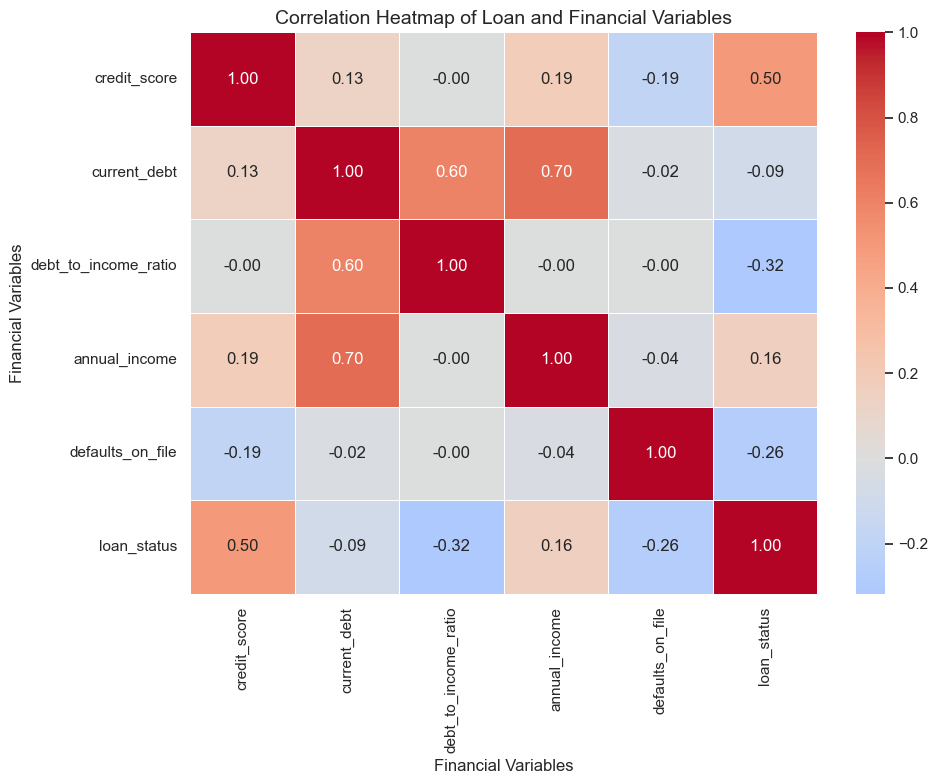

In [20]:
correlation_matrix = correlation_data.corr()

plt.figure(figsize=(10, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Correlation Heatmap of Loan and Financial Variables", fontsize=14)
plt.xlabel("Financial Variables")
plt.ylabel("Financial Variables")
plt.tight_layout()
plt.show()

### 3.1 Outlier Analysis

I created boxplots for the main numerical variables to identify outliers. 
Boxplots show the median, the interquartile range, and any points that 
fall far outside the normal range.

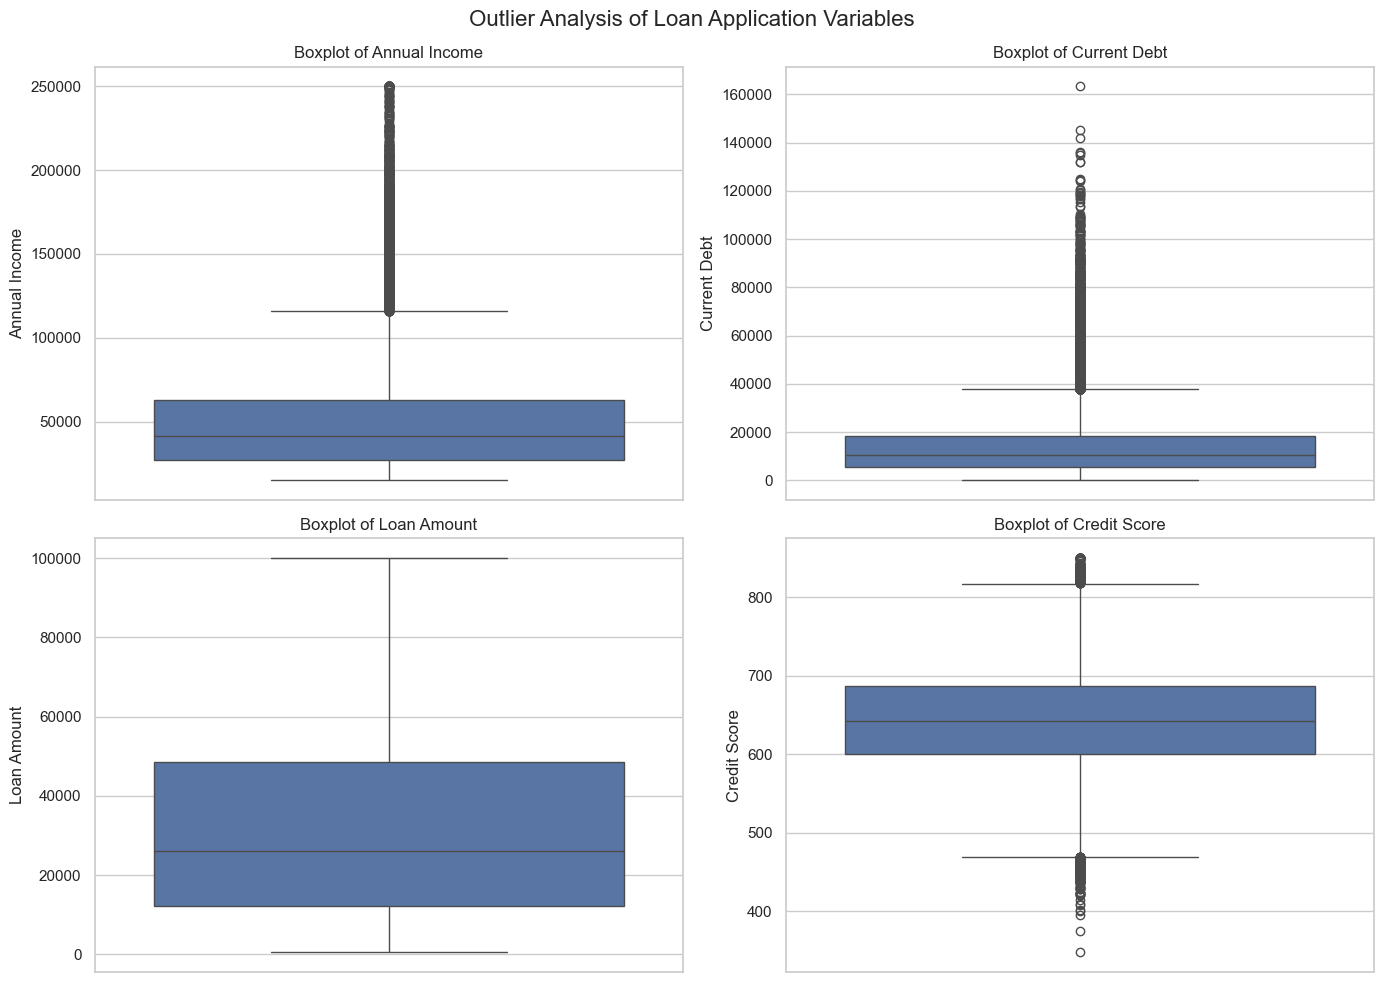

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

outlier_columns = [
    "annual_income",
    "current_debt",
    "loan_amount",
    "credit_score"
]

chart_titles = [
    "Boxplot of Annual Income",
    "Boxplot of Current Debt",
    "Boxplot of Loan Amount",
    "Boxplot of Credit Score"
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for axis, column, title in zip(axes, outlier_columns, chart_titles):
    sns.boxplot(
        data=df_clean,
        y=column,
        ax=axis
    )

    axis.set_title(title)
    axis.set_xlabel("")
    axis.set_ylabel(column.replace("_", " ").title())

plt.suptitle("Outlier Analysis of Loan Application Variables", fontsize=16)
plt.tight_layout()
plt.show()

## 4. Modeling

In this section, I build and compare three regression models to predict 
interest_rate: Linear Regression, Polynomial Regression, and Ridge 
Regression. I chose these three models because they represent increasing 
levels of complexity, allowing me to compare a simple linear approach 
against models that can capture non-linear patterns or reduce overfitting.

I split the data into 80% for training and 20% for testing, so the 
models are evaluated on data they have never seen before.

In [25]:
import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, PolynomialFeatures, StandardScaler

# Predictor variables
features = [
    "credit_score",
    "annual_income",
    "current_debt",
    "debt_to_income_ratio",
    "loan_amount",
    "defaults_on_file",
    "delinquencies_last_2yrs",
    "derogatory_marks"
]

# Target variable
target = "interest_rate"

# Create X containing the predictors and y containing the target
X = df_clean[features].copy()
y = pd.to_numeric(df_clean[target], errors="coerce")

# Remove rows where the target interest rate is missing or non-numeric
valid_target = y.notna()
X = X.loc[valid_target].copy()
y = y.loc[valid_target].copy()

print("Feature data shape:", X.shape)
print("Target data shape:", y.shape)

Feature data shape: (50000, 8)
Target data shape: (50000,)


In [26]:
# Split the dataset:
# 80% is used to train the models
# 20% is used to evaluate the models
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

Training set shape: (40000, 8)
Testing set shape: (10000, 8)


In [27]:
# Automatically identify numeric and categorical predictors
numeric_features = X_train.select_dtypes(include=np.number).columns.tolist()
categorical_features = X_train.select_dtypes(exclude=np.number).columns.tolist()

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

# Numeric preprocessing:
# 1. Replace missing values with the median
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ]
)

# Categorical preprocessing:
# 1. Replace missing values with the most frequent category
# 2. Convert categories into numeric dummy variables
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)

# Apply the appropriate preprocessing to each type of column
preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_transformer, numeric_features),
        ("categorical", categorical_transformer, categorical_features)
    ],
    remainder="drop"
)

Numeric features: ['credit_score', 'annual_income', 'current_debt', 'debt_to_income_ratio', 'loan_amount', 'defaults_on_file', 'delinquencies_last_2yrs', 'derogatory_marks']
Categorical features: []


In [30]:
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)

In [31]:
# 1. Linear Regression pipeline
linear_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

# 2. Polynomial Regression pipeline
# PolynomialFeatures creates squared terms and interaction terms.
# LinearRegression then fits those polynomial features.
polynomial_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "polynomial_features",
            PolynomialFeatures(
                degree=2,
                include_bias=False
            )
        ),
        ("model", LinearRegression())
    ]
)

# 3. Ridge Regression pipeline
# StandardScaler standardizes the processed predictors.
# Ridge applies L2 regularization with alpha=1.0.
ridge_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=1.0))
    ]
)

In [32]:
# Store the models in a dictionary so they can be trained
# and evaluated using the same process
models = {
    "Linear Regression": linear_model,
    "Polynomial Regression (Degree 2)": polynomial_model,
    "Ridge Regression": ridge_model
}

# Store the evaluation results
results = []

for model_name, model in models.items():
    
    # Train the model using the training data
    model.fit(X_train, y_train)
    
    # Predict interest rates for the test data
    y_pred = model.predict(X_test)
    
    # Calculate the evaluation metrics
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    # Print the results for the current model
    print(f"\n{model_name}")
    print("-" * len(model_name))
    print(f"RMSE: {rmse:.4f}")
    print(f"MAE:  {mae:.4f}")
    print(f"R²:   {r2:.4f}")
    
    # Add the results to the comparison list
    results.append(
        {
            "Model": model_name,
            "RMSE": rmse,
            "MAE": mae,
            "R2 Score": r2
        }
    )


Linear Regression
-----------------
RMSE: 3.5316
MAE:  3.2950
R²:   0.2430

Polynomial Regression (Degree 2)
--------------------------------
RMSE: 3.5183
MAE:  3.2716
R²:   0.2487

Ridge Regression
----------------
RMSE: 3.5316
MAE:  3.2950
R²:   0.2430


### 4.1 Model Comparison

After training the three models, I compare their performance using 
RMSE, MAE and R2 score on the test set.

In [33]:
# Convert the evaluation results into a DataFrame
comparison_table = pd.DataFrame(results)

# Sort from lowest RMSE to highest RMSE
comparison_table = comparison_table.sort_values(
    by="RMSE",
    ascending=True
).reset_index(drop=True)

# Round the metrics for easier reading
comparison_table[["RMSE", "MAE", "R2 Score"]] = (
    comparison_table[["RMSE", "MAE", "R2 Score"]].round(4)
)

print("Regression Model Comparison:")
display(comparison_table)

Regression Model Comparison:


,Model,RMSE,MAE,R2 Score
0,Polynomial Regression (Degree 2),3.5183,3.2716,0.2487
1,Ridge Regression,3.5316,3.2950,0.2430
2,Linear Regression,3.5316,3.2950,0.2430


## 5. Hyperparameter Tuning

Ridge Regression has a parameter called alpha that controls how much 
the model is penalized for having large coefficients. A higher alpha 
makes the model simpler and less likely to overfit, but if it is too 
high the model can underfit.

I use GridSearchCV to test different alpha values (0.01, 0.1, 1, 10, 100) 
and find the one that gives the best cross-validation performance.

In [34]:
import numpy as np

from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Create a pipeline using the previously defined preprocessor
ridge_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("scaler", StandardScaler()),
        ("ridge", Ridge())
    ]
)

# Define the alpha values to test
parameter_grid = {
    "ridge__alpha": [0.01, 0.1, 1, 10, 100]
}

# Perform 5-fold cross-validation.
# Ridge uses R² as its default scoring metric.
grid_search = GridSearchCV(
    estimator=ridge_pipeline,
    param_grid=parameter_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

# Train and evaluate each alpha value using cross-validation
grid_search.fit(X_train, y_train)

# Print the best tuning results
best_alpha = grid_search.best_params_["ridge__alpha"]

print("Best alpha value:", best_alpha)
print(f"Best cross-validation R² score: {grid_search.best_score_:.4f}")

# Create and retrain Ridge Regression using the best alpha
best_ridge_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("scaler", StandardScaler()),
        ("ridge", Ridge(alpha=best_alpha))
    ]
)

best_ridge_model.fit(X_train, y_train)

# Predict interest rates for the test set
y_pred_best_ridge = best_ridge_model.predict(X_test)

# Calculate test-set evaluation metrics
rmse = np.sqrt(mean_squared_error(y_test, y_pred_best_ridge))
mae = mean_absolute_error(y_test, y_pred_best_ridge)
r2 = r2_score(y_test, y_pred_best_ridge)

print("\nBest Ridge Regression Test Results")
print("----------------------------------")
print(f"RMSE: {rmse:.4f}")
print(f"MAE:  {mae:.4f}")
print(f"R²:   {r2:.4f}")

Best alpha value: 100
Best cross-validation R² score: 0.2487

Best Ridge Regression Test Results
----------------------------------
RMSE: 3.5316
MAE:  3.2952
R²:   0.2431


## 6. Single-Variable vs Multi-Variable Comparison

To understand how much value the additional features add, I compare a 
simple model using only credit_score against a model using all 8 features.

In [35]:
import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder


# ---------------------------------------------------------
# 1. Define the target and the two feature sets
# ---------------------------------------------------------

target = "interest_rate"

single_feature = [
    "credit_score"
]

multi_features = [
    "credit_score",
    "annual_income",
    "current_debt",
    "debt_to_income_ratio",
    "loan_amount",
    "defaults_on_file",
    "delinquencies_last_2yrs",
    "derogatory_marks"
]


# ---------------------------------------------------------
# 2. Prepare the data
# ---------------------------------------------------------

# Convert the target to numeric
y = pd.to_numeric(df_clean[target], errors="coerce")

# Keep only rows with a valid target value
valid_rows = y.notna()

X_single = df_clean.loc[valid_rows, single_feature].copy()
X_multi = df_clean.loc[valid_rows, multi_features].copy()
y = y.loc[valid_rows].copy()


# ---------------------------------------------------------
# 3. Create the same train/test split for both approaches
# ---------------------------------------------------------

# Split row indexes so both models use exactly the same observations
train_index, test_index = train_test_split(
    np.arange(len(y)),
    test_size=0.20,
    random_state=42
)

X_single_train = X_single.iloc[train_index]
X_single_test = X_single.iloc[test_index]

X_multi_train = X_multi.iloc[train_index]
X_multi_test = X_multi.iloc[test_index]

y_train = y.iloc[train_index]
y_test = y.iloc[test_index]


# ---------------------------------------------------------
# 4. Single-variable Linear Regression
# ---------------------------------------------------------

single_model = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "linear_regression",
            LinearRegression()
        )
    ]
)

single_model.fit(X_single_train, y_train)

single_predictions = single_model.predict(X_single_test)


# ---------------------------------------------------------
# 5. Multi-variable preprocessing
# ---------------------------------------------------------

numeric_features = [
    "credit_score",
    "annual_income",
    "current_debt",
    "debt_to_income_ratio",
    "loan_amount",
    "delinquencies_last_2yrs",
    "derogatory_marks"
]

categorical_features = [
    "defaults_on_file"
]

numeric_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        )
    ]
)

categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)

multi_preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_transformer,
            numeric_features
        ),
        (
            "categorical",
            categorical_transformer,
            categorical_features
        )
    ]
)


# ---------------------------------------------------------
# 6. Multi-variable Linear Regression
# ---------------------------------------------------------

multi_model = Pipeline(
    steps=[
        (
            "preprocessor",
            multi_preprocessor
        ),
        (
            "linear_regression",
            LinearRegression()
        )
    ]
)

multi_model.fit(X_multi_train, y_train)

multi_predictions = multi_model.predict(X_multi_test)


# ---------------------------------------------------------
# 7. Calculate RMSE, MAE, and R²
# ---------------------------------------------------------

single_rmse = np.sqrt(
    mean_squared_error(y_test, single_predictions)
)
single_mae = mean_absolute_error(
    y_test,
    single_predictions
)
single_r2 = r2_score(
    y_test,
    single_predictions
)

multi_rmse = np.sqrt(
    mean_squared_error(y_test, multi_predictions)
)
multi_mae = mean_absolute_error(
    y_test,
    multi_predictions
)
multi_r2 = r2_score(
    y_test,
    multi_predictions
)


# ---------------------------------------------------------
# 8. Create and print the comparison table
# ---------------------------------------------------------

comparison_table = pd.DataFrame(
    {
        "Model": [
            "Single Variable: Credit Score",
            "Multi Variable: 8 Features"
        ],
        "RMSE": [
            single_rmse,
            multi_rmse
        ],
        "MAE": [
            single_mae,
            multi_mae
        ],
        "R2 Score": [
            single_r2,
            multi_r2
        ]
    }
)

comparison_table[["RMSE", "MAE", "R2 Score"]] = (
    comparison_table[["RMSE", "MAE", "R2 Score"]].round(4)
)

print("Single-Variable vs Multi-Variable Regression")
display(comparison_table)

Single-Variable vs Multi-Variable Regression


,Model,RMSE,MAE,R2 Score
0,Single Variable: Credit Score,3.5402,3.3313,0.2393
1,Multi Variable: 8 Features,3.5316,3.2950,0.2430


## 7. Conclusion

The Polynomial Regression model performed slightly better than Linear 
and Ridge Regression, with the lowest RMSE and highest R2 score. However, 
all three models had relatively low R2 scores (around 0.24), which means 
interest_rate depends on many factors beyond what is captured in this 
dataset.

The Grid Search showed that the best alpha for Ridge Regression was 100, 
but this did not improve performance much compared to the default model. 

Comparing single-variable and multi-variable approaches showed that using 
all 8 features gives a small improvement over using credit_score alone, 
which confirms that credit_score is the most important predictor but 
not the only one that matters.

A limitation of this analysis is that interest_rate may depend on factors 
not included in this dataset, such as the lender's specific pricing policy 
or current market interest rates.